# Clase aplicada 1: Aplicaciones de modelos de series de tiempo

En esta clase aplicada se concretan los contenidos conceptuales iniciales del curso mediante dos ejemplos reales:

1. **Generación de Energía Eléctrica (GEE)** en Chile.
2. **Índice de Oscilación Sur (SOI)**.

El objetivo es construir una primera estrategia de predicción usando modelos ingenuos de series de tiempo, separando explícitamente una muestra de entrenamiento y una muestra de prueba.

La idea central es que el análisis de una serie de tiempo no comienza con el modelo, sino con la comprensión de la estructura temporal de los datos: presencia de tendencia, patrones repetitivos, variabilidad y horizonte de predicción relevante.

En este notebook se trabajará con copias locales de las series originales. La idea es que todos los resultados, gráficos y predicciones coincidan con los utilizados al construir la clase, evitando diferencias producidas por futuras actualizaciones de las bases de datos.

## 1. Librerías y directorios

En esta sección se cargan las librerías necesarias y se definen las rutas de trabajo.

En este notebook se asumirá una estructura como la siguiente:

```text
SeriesTiempoPython/
│
├── data/
│   └── raw/
│       ├── G034GETOFLUCDECZ0M.xlsx
│       └── soi.data.txt
│
└── notebooks/
    └── ClaseAplicada01.ipynb
```

El notebook utilizará archivos locales para asegurar reproducibilidad y mantener exactamente el mismo período temporal utilizado al construir el material docente.

El siguiente código define las rutas de trabajo y crea la carpeta `data/raw` en caso de que no exista.

In [11]:
# Librerías necesarias

# Manejo de rutas y directorios
from pathlib import Path

# Permite leer texto como si fuera un archivo
from io import StringIO

# Computación numérica
import numpy as np

# Manipulación y análisis de datos
import pandas as pd

# Visualización de gráficos
import matplotlib.pyplot as plt

# Modelos de suavizamiento exponencial
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    ExponentialSmoothing
)

# Error cuadrático medio
from sklearn.metrics import mean_squared_error

In [2]:
# Carpeta principal del proyecto.
# En este notebook se asumirá que el notebook se ejecuta desde la carpeta `notebooks/`.
ROOT = Path.cwd().parent

# Datos
RAW = ROOT / "data" / "raw"

ROOT

PosixPath('/Users/Jonat/Documents/Docencia/UC/Magister Coursera 2/Python - Coursera/Series de Tiempo/Clases Aplicaciones')

## 2. Configuraciones generales y Funciones auxiliares

Para evitar repetir código, se definen algunas funciones auxiliares para construir tablas, calcular errores y graficar las series.

Estas funciones no son el foco estadístico de la clase, sino que permiten ordenar el análisis aplicado.

In [3]:
# Configuración general de gráficos
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

def tabla_ajuste(serie, fitted, nombre_serie):
    """
    Construye una tabla con valores observados, valores ajustados y errores de ajuste.
    """
    fitted = fitted.reindex(serie.index)

    tabla = pd.DataFrame({
        "Fecha": serie.index,
        nombre_serie: serie.values,
        "Ajuste": fitted.values
    })
    tabla["Error"] = tabla[nombre_serie] - tabla["Ajuste"]
    return tabla


def tabla_prediccion(serie_test, pred, nombre_serie):
    """
    Construye una tabla con valores observados, predichos y errores de predicción.
    """
    pred = pd.Series(pred, index=serie_test.index)

    tabla = pd.DataFrame({
        "Fecha": serie_test.index,
        nombre_serie: serie_test.values,
        "Predictor": pred.values
    })
    tabla["Error"] = tabla[nombre_serie] - tabla["Predictor"]
    return tabla


def mse(y_true, y_pred):
    """
    Calcula el error cuadrático medio.
    """
    return mean_squared_error(y_true, y_pred)


def graficar_train_test(train, test, titulo, ylabel, xlim=None, fecha_corte=None):
    """
    Grafica una serie separando muestra de entrenamiento y muestra de prueba.
    """
    fig, ax = plt.subplots()
    ax.plot(train.index, train.values, label="Entrenamiento", color="black")
    ax.plot(test.index, test.values, label="Prueba", color="red")

    if fecha_corte is not None:
        ax.axvline(fecha_corte, linestyle="--", color="black", linewidth=1)

    if xlim is not None:
        ax.set_xlim(xlim)

    ax.set_title(titulo)
    ax.set_xlabel("Fecha")
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.show()


def graficar_ajuste_prediccion(train, fitted, test, pred, titulo, ylabel, xlim=None, ylim=None):
    """
    Grafica la serie de entrenamiento, el ajuste, la muestra de prueba y la predicción.
    """
    fig, ax = plt.subplots()

    ax.plot(train.index, train.values, label="Entrenamiento", color="black")
    ax.plot(fitted.index, fitted.values, label="Ajuste", color="blue")
    ax.plot(test.index, test.values, label="Prueba", color="red")
    ax.plot(pred.index, pred.values, label="Predicción", color="green")

    ax.axvline(test.index[0], linestyle="--", color="black", linewidth=1)

    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(titulo)
    ax.set_xlabel("Fecha")
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.show()

## 3. Contexto de la serie GEE

La serie **Generación de Energía Eléctrica (GEE)** corresponde a la medición mensual de la generación real de las centrales generadoras del sistema eléctrico nacional.

Los datos se encuentran disponibles en la página del Banco Central de Chile y se puede acceder directamente a ellos mediante el siguiente enlace:

https://si3.bcentral.cl/siete/ES/Siete/Cuadro/CAP_IND_SEC/MN_IND_SEC20/IS_ENE?idSerie=G034.GETO.FLU.CDEC.Z.0.M

En este notebook se trabajará con una copia local del archivo Excel descargado previamente, para evitar que la ejecución dependa de una conexión a internet o de cambios en la página web.

Desde el punto de vista aplicado, esta serie será usada como un **proxy de la demanda agregada de energía eléctrica**, ya que en los sistemas eléctricos la generación debe ajustarse continuamente a la demanda.

### Horizonte de predicción para GEE

Para este caso se considerará como objetivo predecir la generación eléctrica mensual durante los próximos **12 meses**.

Este horizonte es razonable porque la serie presenta:

- una tendencia creciente persistente;
- un patrón anual visible;
- una frecuencia mensual, por lo que 12 meses corresponden a un ciclo completo.

Por esta razón, se separarán los últimos 12 datos disponibles como conjunto de prueba.

In [4]:
archivo_gee = RAW / "G034GETOFLUCDECZ0M.xlsx"

df_gee = pd.read_excel(archivo_gee, skiprows=2)
df_gee.head()

,Periodo,Generación de energía eléctrica CDEC (GWh)
0,1999-01-01,2921.407178
1,1999-02-01,2724.396644
2,1999-03-01,3088.649801
3,1999-04-01,2856.741089
4,1999-05-01,2965.867600


In [5]:
df_gee.tail()

,Periodo,Generación de energía eléctrica CDEC (GWh)
320,2025-09-01,6762.2
321,2025-10-01,7029.2
322,2025-11-01,6968.1
323,2025-12-01,7515.4
324,2026-01-01,7433.5


In [6]:
col_gee = "Generación de energía eléctrica CDEC (GWh)"

# Serie mensual desde enero de 1999.
# Se asume que el archivo está ordenado cronológicamente y contiene una observación por mes.
idx_gee = pd.date_range(start="1999-01-01", periods=len(df_gee), freq="MS")

ts_gee = pd.Series(
    df_gee[col_gee].to_numpy(),
    index=idx_gee,
    name="GEE"
)

ts_gee.head()

1999-01-01    2921.407178
1999-02-01    2724.396644
1999-03-01    3088.649801
1999-04-01    2856.741089
1999-05-01    2965.867600
Freq: MS, Name: GEE, dtype: float64

In [7]:
n_gee = len(ts_gee)

ts_gee_train = ts_gee.iloc[:n_gee - 12]
ts_gee_test = ts_gee.iloc[n_gee - 12:]

print(f"Número total de observaciones: {len(ts_gee)}")
print(f"Entrenamiento: {ts_gee_train.index[0].strftime('%Y-%m')} a {ts_gee_train.index[-1].strftime('%Y-%m')}")
print(f"Prueba:        {ts_gee_test.index[0].strftime('%Y-%m')} a {ts_gee_test.index[-1].strftime('%Y-%m')}")

Número total de observaciones: 325
Entrenamiento: 1999-01 a 2025-01
Prueba:        2025-02 a 2026-01


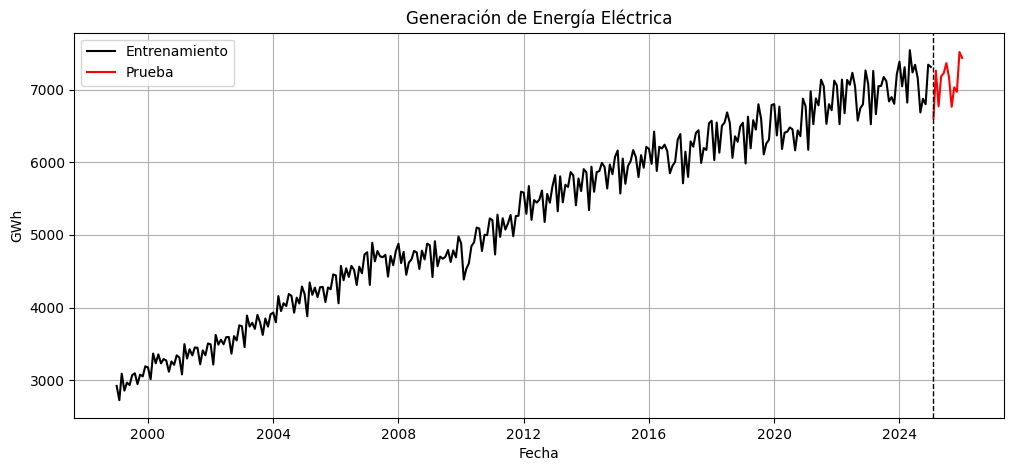

In [8]:
graficar_train_test(
    ts_gee_train,
    ts_gee_test,
    titulo="Generación de Energía Eléctrica",
    ylabel="GWh",
    fecha_corte=ts_gee_test.index[0]
)

**Comentario.**  
La gráfica muestra una tendencia creciente y variaciones que se repiten de forma regular a lo largo de los años. Esto sugiere que un modelo razonable debe ser capaz de representar simultáneamente tendencia y estacionalidad.

Además, la amplitud de los cambios estacionales parece aumentar con el nivel de la serie. Esta es una señal favorable para considerar una componente estacional multiplicativa.

## 4. Contexto de la serie SOI

La serie **SOI** corresponde al *Southern Oscillation Index* o **Índice de Oscilación Sur**.

Este indicador climático se utiliza para monitorear la variabilidad atmosférica en el océano Pacífico tropical y se construye a partir de diferencias de presión atmosférica a nivel del mar entre Tahití y Darwin.

El índice SOI es uno de los principales indicadores del fenómeno **El Niño-Oscilación del Sur (ENSO)**, con impactos relevantes sobre precipitaciones, temperaturas y eventos extremos.

Los datos actualizados se pueden obtener desde NOAA en el siguiente enlace:

https://psl.noaa.gov/data/correlation/soi.data

Para asegurar la reproducibilidad del notebook, se recomienda descargar el archivo `soi.data.txt` y guardarlo localmente en `data/raw/`.

### Opción recomendada:
1. Descargar manualmente soi.data desde NOAA.
2. Guardarlo en data/raw/soi.data.
3. Leer siempre desde el archivo local.

### Horizonte de predicción para SOI

A diferencia de la serie GEE, la serie SOI no presenta una tendencia clara y fluctúa alrededor de cero. Este tipo de serie suele tener una capacidad predictiva más concentrada en pocos pasos hacia adelante.

Por esta razón, en esta clase se dejarán solo los últimos **2 meses** como conjunto de prueba.

Esta decisión permite evaluar predicciones de corto plazo, coherentes con la estructura de la serie.

In [12]:
archivo_soi = RAW / "soi.data.txt"

with open(archivo_soi, "r", encoding="utf-8") as f:
    raw = f.readlines()

# Mantener solo líneas con estructura: año + 12 valores mensuales
raw_num = []
for line in raw:
    partes = line.split()

    if len(partes) == 13 and partes[0].isdigit():
        raw_num.append(line)

soi_raw = pd.read_csv(
    StringIO("".join(raw_num)),
    sep=r"\s+",
    header=None,
    engine="python"
)

soi_raw.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1948,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99
1,1949,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99
2,1950,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99
3,1951,2.50,1.50,-0.20,-0.50,-1.10,0.30,-1.70,-0.40,-1.80,-1.60,-1.30,-1.20
4,1952,-1.50,-1.00,0.90,-0.40,1.20,1.20,0.80,0.10,-0.40,0.60,0.00,-2.00


In [13]:
soi_raw.columns = ["Anio"] + [f"M{m}" for m in range(1, 13)]  
soi_raw.tail()

,Anio,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
74,2022,0.8,1.8,2.90,2.80,2.40,2.80,1.30,1.70,2.70,2.80,0.50,3.50
75,2023,2.3,2.3,0.30,0.40,-1.70,0.40,-0.40,-1.40,-2.10,-0.80,-1.30,-0.40
76,2024,0.8,-2.3,0.60,-0.30,0.80,0.10,-1.20,1.50,-0.20,0.80,0.80,1.90
77,2025,0.3,0.9,2.80,0.90,0.70,0.50,1.00,0.70,0.10,1.90,1.80,-0.00
78,2026,1.8,2.4,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99,-99.99


In [14]:
# Entrenamiento: enero 1951 a diciembre 2025
soi_values_train = soi_raw.loc[
    (soi_raw["Anio"] >= 1951) & (soi_raw["Anio"] <= 2025),
    "M1":"M12"].to_numpy().ravel()

# Test: enero y febrero de 2026
soi_values_test = soi_raw.loc[
    soi_raw["Anio"] == 2026,
    ["M1", "M2"]].to_numpy().ravel()

In [15]:
# En la clase se utiliza la serie desde enero de 1951.
# Se dejan como prueba los dos primeros meses de 2026.

idx_soi_train = pd.date_range(start="1951-01-01", periods=len(soi_values_train), freq="MS")
idx_soi_test = pd.date_range(start="2026-01-01", periods=len(soi_values_test), freq="MS")

ts_soi_train = pd.Series(soi_values_train, index=idx_soi_train, name="SOI")
ts_soi_test = pd.Series(soi_values_test, index=idx_soi_test, name="SOI")
ts_soi_new = pd.concat([ts_soi_train, ts_soi_test])

print(f"Número total de observaciones: {len(ts_soi_new)}")
print(f"Entrenamiento: {ts_soi_train.index[0].strftime('%Y-%m')} a {ts_soi_train.index[-1].strftime('%Y-%m')}")
print(f"Prueba:        {ts_soi_test.index[0].strftime('%Y-%m')} a {ts_soi_test.index[-1].strftime('%Y-%m')}")

Número total de observaciones: 902
Entrenamiento: 1951-01 a 2025-12
Prueba:        2026-01 a 2026-02


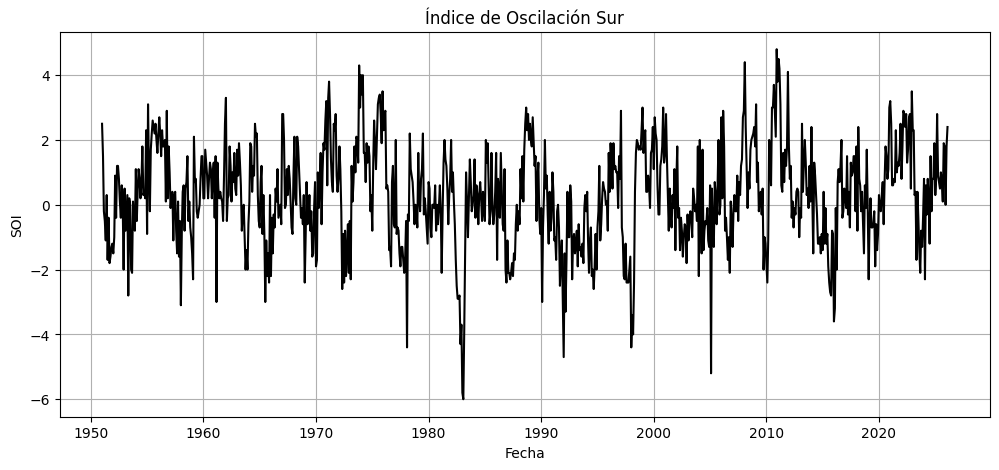

In [16]:
fig, ax = plt.subplots()
ax.plot(ts_soi_new.index, ts_soi_new.values, color="black")
ax.set_title("Índice de Oscilación Sur")
ax.set_xlabel("Fecha")
ax.set_ylabel("SOI")
plt.show()

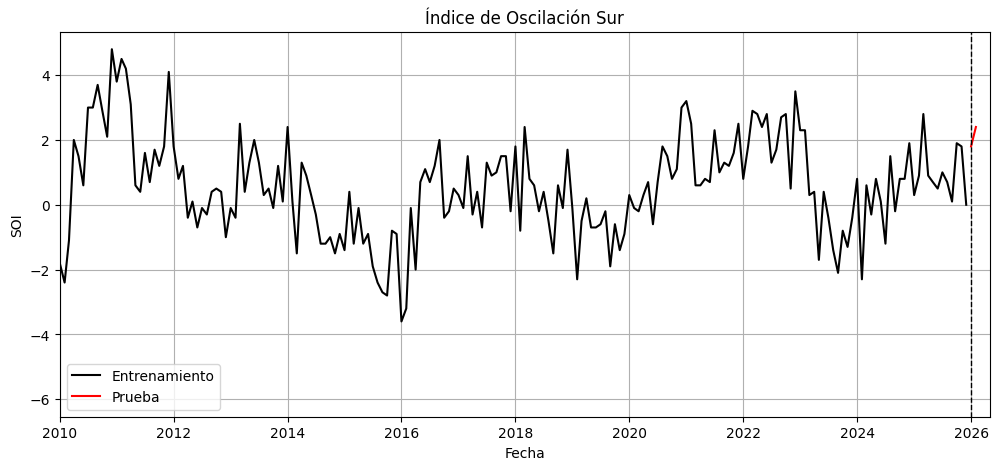

In [18]:
graficar_train_test(
    ts_soi_train,
    ts_soi_test,
    titulo="Índice de Oscilación Sur",
    ylabel="SOI",
    xlim=(pd.Timestamp("2010-01-01"), pd.Timestamp("2026-05-01")),
    fecha_corte=ts_soi_test.index[0]
)

## 5. Ajuste de la serie SOI: suavizamiento exponencial simple

Para una serie sin tendencia clara ni componente estacional evidente, el modelo ingenuo apropiado dentro de la familia de suavizamientos exponenciales es el **suavizamiento exponencial simple**.

Este modelo depende de un único parámetro, generalmente denotado por $\alpha$:

- si $\alpha$ es cercano a 1, el predictor entrega mucho peso al pasado reciente;
- si $\alpha$ es cercano a 0, el predictor entrega más peso al pasado remoto.

En Python se ajustará mediante `SimpleExpSmoothing` de `statsmodels`.

In [20]:
?SimpleExpSmoothing

Init signature: SimpleExpSmoothing(endog, initialization_method=None, initial_level=None)
Docstring:     
Simple Exponential Smoothing

Parameters
----------
endog : array_like
    The time series to model.
initialization_method : str, optional
    Method for initialize the recursions. One of:

    * None
    * 'estimated'
    * 'heuristic'
    * 'legacy-heuristic'
    * 'known'

    None defaults to the pre-0.12 behavior where initial values
    are passed as part of ``fit``. If any of the other values are
    passed, then the initial values must also be set when constructing
    the model. If 'known' initialization is used, then `initial_level`
    must be passed, as well as `initial_trend` and `initial_seasonal` if
    applicable. Default is 'estimated'. "legacy-heuristic" uses the same
    values that were used in statsmodels 0.11 and earlier.
initial_level : float, optional
    The initial level component. Required if estimation method is "known".
    If set using either "estimate

In [21]:
modelo_soi = SimpleExpSmoothing(
    ts_soi_train,
    initialization_method="legacy-heuristic").fit(optimized=True)

alpha_soi = modelo_soi.params["smoothing_level"]

print(f"Alpha estimado: {alpha_soi:.4f}")

Alpha estimado: 0.4735


### Modelo alternativo para SOI

Como contraste, se ajusta un modelo con componente estacional aditiva de periodo 12. Este modelo no se considera apropiado para SOI en esta etapa, pero permite ilustrar que agregar estructura innecesaria no necesariamente mejora la predicción.

In [22]:
modelo_soi_alt = ExponentialSmoothing(
    ts_soi_train,
    trend=None,
    seasonal="add",
    seasonal_periods=12,
    initialization_method="legacy-heuristic"
).fit(optimized=True)

modelo_soi_alt.params

{'smoothing_level': 0.42254226849107224,
 'smoothing_trend': nan,
 'smoothing_seasonal': 0.11558856741443187,
 'damping_trend': nan,
 'initial_level': 0.25066666666666665,
 'initial_trend': nan,
 'initial_seasons': array([ 2.24933333,  1.24933333, -0.45066667, -0.75066667, -1.35066667,
         0.04933333, -1.95066667, -0.65066667, -2.05066667, -1.85066667,
        -1.55066667, -1.45066667]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

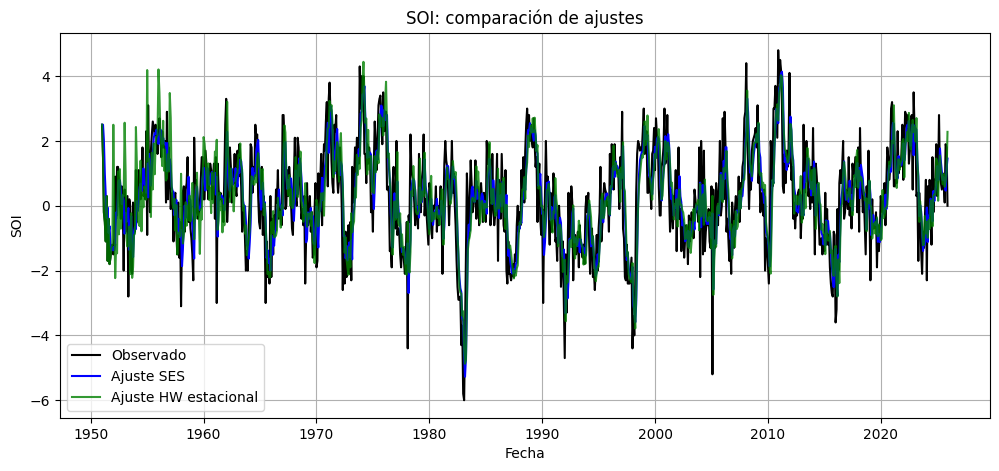

In [23]:
fig, ax = plt.subplots()
ax.plot(ts_soi_train.index, ts_soi_train.values, label="Observado", color="black")
ax.plot(modelo_soi.fittedvalues.index, modelo_soi.fittedvalues.values, label="Ajuste SES", color="blue")
ax.plot(modelo_soi_alt.fittedvalues.index, modelo_soi_alt.fittedvalues.values, label="Ajuste HW estacional", color="green", alpha=0.8)

ax.set_title("SOI: comparación de ajustes")
ax.set_xlabel("Fecha")
ax.set_ylabel("SOI")
ax.legend()
plt.show()

In [24]:
tabla_fit_soi = tabla_ajuste(ts_soi_train, modelo_soi.fittedvalues, "SOI")

display(tabla_fit_soi.head(5).round(2))
display(tabla_fit_soi.tail(5).round(2))

,Fecha,SOI,Ajuste,Error
0,1951-01-01,2.5,2.50,0.00
1,1951-02-01,1.5,2.50,-1.00
2,1951-03-01,-0.2,2.03,-2.23
3,1951-04-01,-0.5,0.97,-1.47
4,1951-05-01,-1.1,0.28,-1.38


,Fecha,SOI,Ajuste,Error
895,2025-08-01,0.7,0.89,-0.19
896,2025-09-01,0.1,0.80,-0.70
897,2025-10-01,1.9,0.47,1.43
898,2025-11-01,1.8,1.15,0.65
899,2025-12-01,-0.0,1.46,-1.46


In [25]:
pred_soi = modelo_soi.forecast(len(ts_soi_test))
pred_soi_alt = modelo_soi_alt.forecast(len(ts_soi_test))

tabla_pred_soi = tabla_prediccion(ts_soi_test, pred_soi, "SOI")

tabla_pred_soi.round(2)

,Fecha,SOI,Predictor,Error
0,2026-01-01,1.8,0.77,1.03
1,2026-02-01,2.4,0.77,1.63


**Comentario.**  
En el suavizamiento exponencial simple, las predicciones a más de un paso son constantes e iguales al último nivel estimado. Por eso, la predicción de enero y febrero de 2026 coincide.

Esto no significa que el modelo suponga que la serie es constante, sino que, con la información disponible y bajo esta estructura, la mejor predicción fuera de muestra queda determinada por el último nivel suavizado.

In [26]:
tabla_mse_soi = pd.DataFrame({
    "Método": ["Apropiado", "No apropiado"],
    "Modelo": ["Suavizamiento exponencial simple", "Holt-Winters estacional aditivo"],
    "MSE_fit": [
        mse(ts_soi_train.iloc[1:], modelo_soi.fittedvalues.iloc[1:]),
        mse(
            ts_soi_train.reindex(modelo_soi_alt.fittedvalues.dropna().index),
            modelo_soi_alt.fittedvalues.dropna()
        )
    ],
    "MSE_pred": [
        mse(ts_soi_test, pred_soi),
        mse(ts_soi_test, pred_soi_alt)
    ]
})

tabla_mse_soi.round(2)

,Método,Modelo,MSE_fit,MSE_pred
0,Apropiado,Suavizamiento exponencial simple,1.38,1.87
1,No apropiado,Holt-Winters estacional aditivo,1.61,2.66


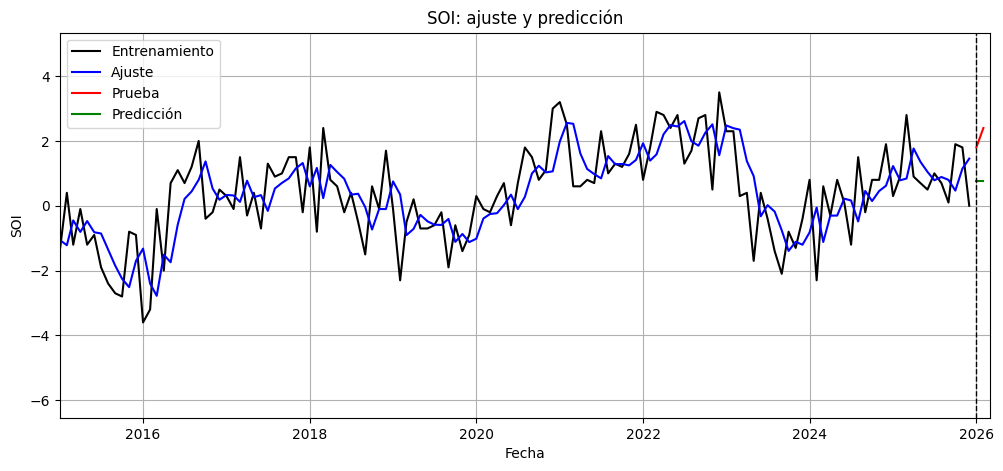

In [27]:
graficar_ajuste_prediccion(
    train=ts_soi_train,
    fitted=modelo_soi.fittedvalues,
    test=ts_soi_test,
    pred=pred_soi,
    titulo="SOI: ajuste y predicción",
    ylabel="SOI",
    xlim=(pd.Timestamp("2015-01-01"), pd.Timestamp("2026-03-01"))
)

**Interpretación para SOI.**  
El suavizamiento exponencial simple es coherente con una serie sin tendencia determinística clara. Sin embargo, la predicción puede alejarse de los valores reales cuando la serie presenta cambios abruptos en los últimos meses.

Esto es esperable: en series de corta memoria, las predicciones útiles suelen concentrarse en horizontes reducidos. A medida que aumenta el horizonte, el predictor tiende a estabilizarse y pierde capacidad para reproducir la variabilidad local de la serie.

## 6. Ajuste de la serie GEE: Holt-Winters multiplicativo

Para la serie GEE se observa:

- tendencia creciente;
- patrón anual;
- amplitud estacional posiblemente creciente con el nivel de la serie;
- valores positivos.

Por estas razones, se propone un modelo de **Holt-Winters multiplicativo** con periodo 12.

El periodo se fija de antemano porque los datos son mensuales y el patrón se repite aproximadamente cada año.

In [28]:
modelo_gee = ExponentialSmoothing(
    ts_gee_train,
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="legacy-heuristic").fit(optimized=True)

params_gee = modelo_gee.params

print(f"Alpha estimado: {params_gee['smoothing_level']:.4f}")
print(f"Beta estimado:  {params_gee['smoothing_trend']:.4f}")
print(f"Gamma estimado: {params_gee['smoothing_seasonal']:.4f}")

Alpha estimado: 0.5354
Beta estimado:  0.0001
Gamma estimado: 0.2445


### Modelo alternativo para GEE

Como contraste, se ajusta un modelo de Holt-Winters aditivo. Este modelo también incorpora tendencia y estacionalidad, pero asume que la amplitud estacional se mantiene aproximadamente constante en el tiempo.

Dado que en la serie GEE la amplitud parece aumentar con el nivel, el modelo multiplicativo es el candidato más natural.

In [29]:
modelo_gee_alt = ExponentialSmoothing(
    ts_gee_train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
    initialization_method="legacy-heuristic").fit(optimized=True)

modelo_gee_alt.params

{'smoothing_level': 0.6060714285714286,
 'smoothing_trend': 0.00010000000000000002,
 'smoothing_seasonal': 0.2626190476190476,
 'damping_trend': nan,
 'initial_level': 5380.829631518986,
 'initial_trend': 20.45947991746465,
 'initial_seasons': array([-2459.42245347, -2656.43298714, -2292.17983052, -2524.0885429 ,
        -2414.96203152, -2447.69363152, -2310.41370938, -2286.34992152,
        -2434.64063641, -2304.77575252, -2328.19857992, -2189.52501952]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

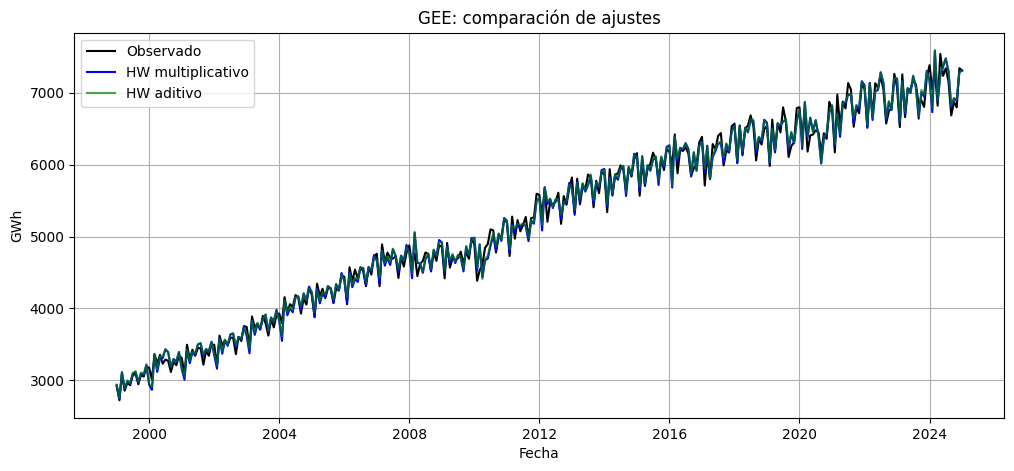

In [31]:
fig, ax = plt.subplots()
ax.plot(ts_gee_train.index, ts_gee_train.values, label="Observado", color="black")
ax.plot(modelo_gee.fittedvalues.index, modelo_gee.fittedvalues.values, label="HW multiplicativo", color="blue")
ax.plot(modelo_gee_alt.fittedvalues.index, modelo_gee_alt.fittedvalues.values, label="HW aditivo", color="green", alpha=0.7)

ax.set_title("GEE: comparación de ajustes")
ax.set_xlabel("Fecha")
ax.set_ylabel("GWh")
ax.legend()
plt.show()

In [32]:
tabla_fit_gee = tabla_ajuste(ts_gee_train, modelo_gee.fittedvalues, "GEE")

tabla_fit_gee.tail(5).round(2)

,Fecha,GEE,Ajuste,Error
308,2024-09-01,6684.9,6797.10,-112.20
309,2024-10-01,6871.8,6922.24,-50.44
310,2024-11-01,6796.8,6886.19,-89.39
311,2024-12-01,7341.1,7285.32,55.78
312,2025-01-01,7310.5,7308.15,2.35


**Comentario.**  
En un modelo Holt-Winters con periodo mensual igual a 12, los primeros valores cumplen el rol de condiciones iniciales. Por esa razón, es más informativo observar los últimos valores ajustados, donde el modelo ya ha actualizado sus componentes de nivel, tendencia y estacionalidad.

In [33]:
pred_gee = modelo_gee.forecast(len(ts_gee_test))
pred_gee_alt = modelo_gee_alt.forecast(len(ts_gee_test))

tabla_pred_gee = tabla_prediccion(ts_gee_test, pred_gee, "GEE")

tabla_pred_gee.round(2)

,Fecha,GEE,Predictor,Error
0,2025-02-01,6601.6,6780.60,-179.00
1,2025-03-01,7258.8,7305.88,-47.08
2,2025-04-01,6767.5,6806.11,-38.61
3,2025-05-01,7179.7,7289.09,-109.39
4,2025-06-01,7226.5,7144.54,81.96
5,2025-07-01,7363.2,7323.76,39.44
6,2025-08-01,7167.3,7216.59,-49.29
7,2025-09-01,6762.2,6796.52,-34.32
8,2025-10-01,7029.2,6999.02,30.18
9,2025-11-01,6968.1,6979.90,-11.80


In [34]:
tabla_mse_gee = pd.DataFrame({
    "Método": ["Apropiado", "No apropiado"],
    "Modelo": ["Holt-Winters multiplicativo", "Holt-Winters aditivo"],
    "MSE_fit": [
        mse(
            ts_gee_train.reindex(modelo_gee.fittedvalues.dropna().index),
            modelo_gee.fittedvalues.dropna()
        ),
        mse(
            ts_gee_train.reindex(modelo_gee_alt.fittedvalues.dropna().index),
            modelo_gee_alt.fittedvalues.dropna()
        )
    ],
    "MSE_pred": [
        mse(ts_gee_test, pred_gee),
        mse(ts_gee_test, pred_gee_alt)
    ]
})

tabla_mse_gee.round(2)

,Método,Modelo,MSE_fit,MSE_pred
0,Apropiado,Holt-Winters multiplicativo,9453.63,5228.97
1,No apropiado,Holt-Winters aditivo,9582.70,11592.05


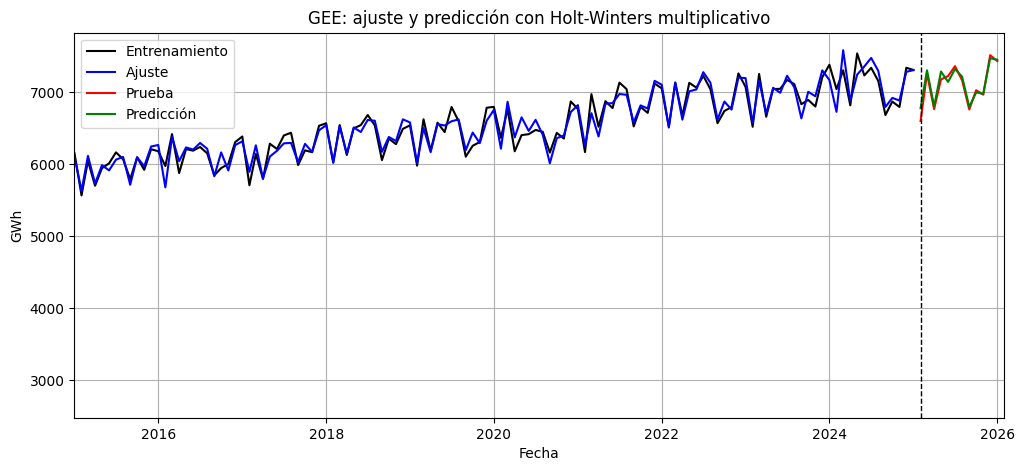

In [28]:
graficar_ajuste_prediccion(
    train=ts_gee_train,
    fitted=modelo_gee.fittedvalues,
    test=ts_gee_test,
    pred=pred_gee,
    titulo="GEE: ajuste y predicción con Holt-Winters multiplicativo",
    ylabel="GWh",
    xlim=(pd.Timestamp("2015-01-01"), ts_gee_test.index[-1] + pd.offsets.MonthBegin(1))
)

**Interpretación para GEE.**  
El modelo Holt-Winters multiplicativo captura tanto la tendencia creciente como el patrón anual de la serie. Además, permite que la magnitud del efecto estacional dependa del nivel de la serie.

Esto contrasta con el caso SOI: aquí sí existe una estructura persistente de largo plazo y un patrón anual claro, por lo que resulta coherente evaluar predicciones a 12 meses.

## 7. Comparación general

Las dos series requieren estrategias distintas:

- SOI se modela inicialmente con suavizamiento exponencial simple, porque no presenta una tendencia clara.
- GEE se modela con Holt-Winters multiplicativo, porque presenta tendencia y estacionalidad anual.

La comparación de errores se realiza respetando la estructura temporal de cada serie.

In [35]:
print("Errores para SOI")
display(tabla_mse_soi.round(2))

print("Errores para GEE")
display(tabla_mse_gee.round(2))

Errores para SOI


,Método,Modelo,MSE_fit,MSE_pred
0,Apropiado,Suavizamiento exponencial simple,1.38,1.87
1,No apropiado,Holt-Winters estacional aditivo,1.61,2.66


Errores para GEE


,Método,Modelo,MSE_fit,MSE_pred
0,Apropiado,Holt-Winters multiplicativo,9453.63,5228.97
1,No apropiado,Holt-Winters aditivo,9582.70,11592.05


## 8. Ideas finales

- En la práctica, el punto de partida del análisis no es el modelo, sino la estructura de los datos.
- Series con tendencia y estacionalidad requieren estrategias distintas a series centradas y sin tendencia clara.
- El horizonte de predicción debe ser coherente con la estructura de la serie y con el uso aplicado del modelo.
- En series de tiempo, la separación entrenamiento-prueba debe respetar el orden temporal.
- Los modelos ingenuos son útiles como punto de partida y como referencia para modelos probabilísticos más avanzados.